<a href="https://colab.research.google.com/github/JLhuis/Parcial-Metodos/blob/main/bcd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Grado  5: cond(V) = 2.90e+03
Grado 10: cond(V) = 2.04e+07
Grado 15: cond(V) = 2.92e+11
Grado 29: cond(V) = 2.50e+19

|Z|(1000 Hz):
  P 5 Matricial: 132.3572 Ω
  P10 Matricial: 131.9781 Ω
  P15 Matricial: 132.0317 Ω
  P29 Matricial: 139.9055 Ω
  P29 Lagrange:  124.7614 Ω
  Spline:        132.0155 Ω  ← referencia

LOO grado 10 — puntos excluidos: [ 355.  810.  985. 1680. 2340.] Hz
   f(Hz)       real       pred      err%
     355   134.8000   134.7494    0.0376%
     810   131.0000   131.0207    0.0158%
     985   131.9000   131.8500    0.0379%
    1680   141.1000   141.0833    0.0118%
    2340   152.2000   152.1106    0.0587%
  Error LOO promedio: 0.0324%  |  máximo: 0.0587%


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/parte_b_interpolacion.png'

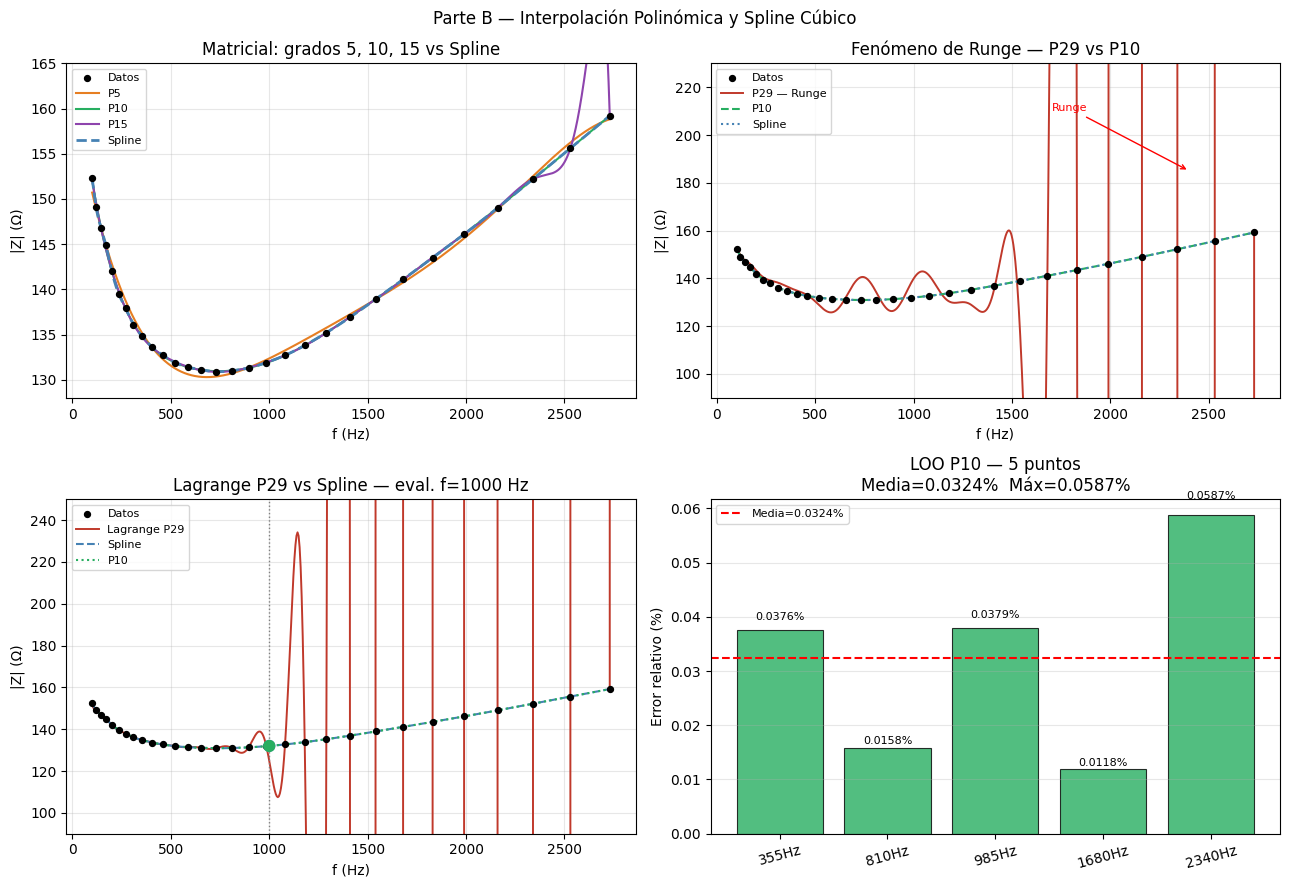

In [ ]:
"""
Métodos Numéricos — Parte B: Interpolación
Autor: [nombre]
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import brentq

np.random.seed(42)

# ── Datos ────────────────────────────────────────────────────────────────────
f = np.array([100,120,145,170,200,235,270,310,355,405,460,520,585,655,730,
              810,895,985,1080,1180,1290,1410,1540,1680,1830,1990,2160,2340,2530,2730], float)
Z = np.array([152.3,149.1,146.8,144.9,142.0,139.5,137.9,136.1,134.8,133.6,
              132.7,131.9,131.4,131.1,130.9,131.0,131.3,131.9,132.7,133.8,
              135.2,136.9,138.9,141.1,143.5,146.1,149.0,152.2,155.6,159.2], float)

# Normalización [0,1]: reduce cond(Vandermonde) de ~10^90 a ~10^7–10^19
t = (f - f[0]) / (f[-1] - f[0])
t1000 = (1000 - f[0]) / (f[-1] - f[0])

ff = np.linspace(f[0], f[-1], 4000)   # malla fina para graficar
tt = (ff - f[0]) / (f[-1] - f[0])

# ════════════════════════════════════════════════════════════════════════════
# B1 — Método Matricial (Vandermonde)
# ════════════════════════════════════════════════════════════════════════════
# Para grado d con n puntos: V[i,j] = t_i^j, resolvemos V·c = Z
# d = n-1 → sistema cuadrado exacto; d < n-1 → sobredeterminado (lstsq)

def poly_matricial(t_nodes, Z_nodes, deg):
    V = np.vander(t_nodes, deg+1, increasing=True)   # columnas: t^0, t^1, ..., t^deg
    c = np.linalg.solve(V, Z_nodes) if deg == len(t_nodes)-1 \
        else np.linalg.lstsq(V, Z_nodes, rcond=None)[0]
    return c   # coeficientes en orden creciente

# Grados a comparar
grados = [5, 10, 15, 29]
coefs = {d: poly_matricial(t, Z, d) for d in grados}

# Evaluar en malla fina: P(t) = V·c usando np.polyval requiere orden decreciente
# → usamos np.vander directamente
eval_p = lambda c, tv: np.vander(tv, len(c), increasing=True) @ c

# Número de condición (evidencia del problema numérico)
for d in grados:
    V = np.vander(t, d+1, increasing=True)
    print(f"Grado {d:2d}: cond(V) = {np.linalg.cond(V):.2e}")

# ════════════════════════════════════════════════════════════════════════════
# B1 — Interpolación de Lagrange (grado 29)
# ════════════════════════════════════════════════════════════════════════════
# P(t) = Σ_k Z_k · L_k(t),   L_k = Π_{j≠k} (t-t_j)/(t_k-t_j)

def lagrange(t_eval, t_nodes, Z_nodes):
    t_eval = np.atleast_1d(t_eval)
    T = t_eval[:, None] - t_nodes[None, :]   # shape (eval, nodes)
    result = np.zeros(len(t_eval))
    for k in range(len(t_nodes)):
        num = np.prod(np.delete(T, k, axis=1), axis=1)
        den = np.prod(np.delete(t_nodes[k] - t_nodes, k))
        result += Z_nodes[k] * num / den
    return result

t500 = np.linspace(t[0], t[-1], 500)   # 500 pts para Lagrange (velocidad)
Z_lag = lagrange(t500, t, Z)

# ════════════════════════════════════════════════════════════════════════════
# B2 — Spline cúbico natural
# ════════════════════════════════════════════════════════════════════════════
cs = CubicSpline(f, Z, bc_type='natural')

# ── Evaluación en f = 1000 Hz ────────────────────────────────────────────────
print("\n|Z|(1000 Hz):")
for d in grados:
    v = eval_p(coefs[d], np.array([t1000]))[0]
    print(f"  P{d:2d} Matricial: {v:.4f} Ω")
print(f"  P29 Lagrange:  {lagrange(np.array([t1000]),t,Z)[0]:.4f} Ω")
print(f"  Spline:        {cs(1000.):.4f} Ω  ← referencia")

# ════════════════════════════════════════════════════════════════════════════
# B1 — Validación LOO con 5 puntos (grado 10 seleccionado)
# ════════════════════════════════════════════════════════════════════════════
# Procedimiento: para cada punto eliminado, ajustar P10 con los 29 restantes
# y predecir en el punto excluido. Error relativo = |pred-real|/real × 100%

idx_loo = np.sort(np.random.choice(30, 5, replace=False))
errs = []
print(f"\nLOO grado 10 — puntos excluidos: {f[idx_loo]} Hz")
print(f"{'f(Hz)':>8}  {'real':>9}  {'pred':>9}  {'err%':>8}")
for i in idx_loo:
    t_tr, Z_tr = np.delete(t, i), np.delete(Z, i)
    c_loo = poly_matricial(t_tr, Z_tr, 10)
    pred = eval_p(c_loo, np.array([t[i]]))[0]
    e = abs(pred - Z[i]) / Z[i] * 100
    errs.append(e)
    print(f"{f[i]:8.0f}  {Z[i]:9.4f}  {pred:9.4f}  {e:8.4f}%")
print(f"  Error LOO promedio: {np.mean(errs):.4f}%  |  máximo: {np.max(errs):.4f}%")

# ════════════════════════════════════════════════════════════════════════════
# Gráficos
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Parte B — Interpolación Polinómica y Spline Cúbico', fontsize=12)
C = {5:'#e67e22', 10:'#27ae60', 15:'#8e44ad', 29:'#c0392b'}

# [0,0] Comparación general grados 5,10,15 vs spline
ax = axes[0,0]
ax.scatter(f, Z, c='k', s=18, zorder=5, label='Datos')
for d in [5,10,15]:
    ax.plot(ff, eval_p(coefs[d], tt), color=C[d], lw=1.5, label=f'P{d}')
ax.plot(ff, cs(ff), 'steelblue', lw=2, ls='--', label='Spline')
ax.set(xlabel='f (Hz)', ylabel='|Z| (Ω)', title='Matricial: grados 5, 10, 15 vs Spline',
       ylim=(128,165)); ax.legend(fontsize=8); ax.grid(alpha=.3)

# [0,1] Fenómeno de Runge
ax = axes[0,1]
ax.scatter(f, Z, c='k', s=18, zorder=5, label='Datos')
ax.plot(ff, eval_p(coefs[29], tt), color=C[29], lw=1.4, label='P29 — Runge')
ax.plot(ff, eval_p(coefs[10], tt), color=C[10], lw=1.5, ls='--', label='P10')
ax.plot(ff, cs(ff), 'steelblue', lw=1.5, ls=':', label='Spline')
ax.set(xlabel='f (Hz)', ylabel='|Z| (Ω)', title='Fenómeno de Runge — P29 vs P10',
       ylim=(90,230)); ax.legend(fontsize=8); ax.grid(alpha=.3)
ax.annotate('Runge', xy=(2400,185), xytext=(1700,210), color='red', fontsize=8,
            arrowprops=dict(arrowstyle='->', color='red'))

# [1,0] Lagrange P29 + zoom 1000 Hz
ax = axes[1,0]
f500 = f[0] + t500*(f[-1]-f[0])
ax.scatter(f, Z, c='k', s=18, zorder=5, label='Datos')
ax.plot(f500, Z_lag, color=C[29], lw=1.4, label='Lagrange P29')
ax.plot(ff, cs(ff), 'steelblue', lw=1.5, ls='--', label='Spline')
ax.plot(ff, eval_p(coefs[10], tt), color=C[10], lw=1.5, ls=':', label='P10')
ax.axvline(1000, color='gray', lw=1, ls=':')
ax.scatter([1000]*2, [cs(1000.), eval_p(coefs[10],np.array([t1000]))[0]],
           c=['steelblue', C[10]], s=60, zorder=6)
ax.set(xlabel='f (Hz)', ylabel='|Z| (Ω)', title='Lagrange P29 vs Spline — eval. f=1000 Hz',
       ylim=(90,250)); ax.legend(fontsize=8); ax.grid(alpha=.3)

# [1,1] LOO bars
ax = axes[1,1]
bars = ax.bar(range(5), errs, color=C[10], alpha=.8, edgecolor='k', lw=.8)
ax.axhline(np.mean(errs), color='red', ls='--', lw=1.5,
           label=f'Media={np.mean(errs):.4f}%')
ax.set_xticks(range(5))
ax.set_xticklabels([f'{int(f[i])}Hz' for i in idx_loo], rotation=15)
ax.set(ylabel='Error relativo (%)', title=f'LOO P10 — 5 puntos\n'
       f'Media={np.mean(errs):.4f}%  Máx={np.max(errs):.4f}%')
for bar, e in zip(bars, errs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.05,
            f'{e:.4f}%', ha='center', fontsize=8)
ax.legend(fontsize=8); ax.grid(alpha=.3, axis='y')

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/parte_b_interpolacion.png', dpi=150, bbox_inches='tight')
print("\nFigura guardada.")

Intervalos con cambio de signo (raíces):
  [113.68, 113.94] Hz
  [2216.57, 2216.84] Hz

─── Raíz 1 ───
  Bisección : 113.6976 Hz  (29 iter)  |Z|=150.0000 Ω
  Newton    : 113.6976 Hz  ( 4 iter)  |Z|=150.0000 Ω

─── Raíz 2 ───
  Bisección : 2216.7413 Hz  (26 iter)  |Z|=150.0000 Ω
  Newton    : 2216.7413 Hz  ( 3 iter)  |Z|=150.0000 Ω

─── Convergencia raíz 2 ───
  it     Bisección x           |g|     it        Newton x           |g|
   1     2225.000000    1.4652e-01      1     2200.000000    2.9634e-01
   2     2187.500000    5.1695e-01      2     2216.768795    4.8806e-04
   3     2206.250000    1.8582e-01      3     2216.741266    1.1917e-09
   4     2215.625000    1.9788e-02      4                              
   5     2220.312500    6.3333e-02      5                              
   6     2217.968750    2.1764e-02      6                              
   7     2216.796875    9.8589e-04      7                              
   8     2216.210938    9.4016e-03      8                     

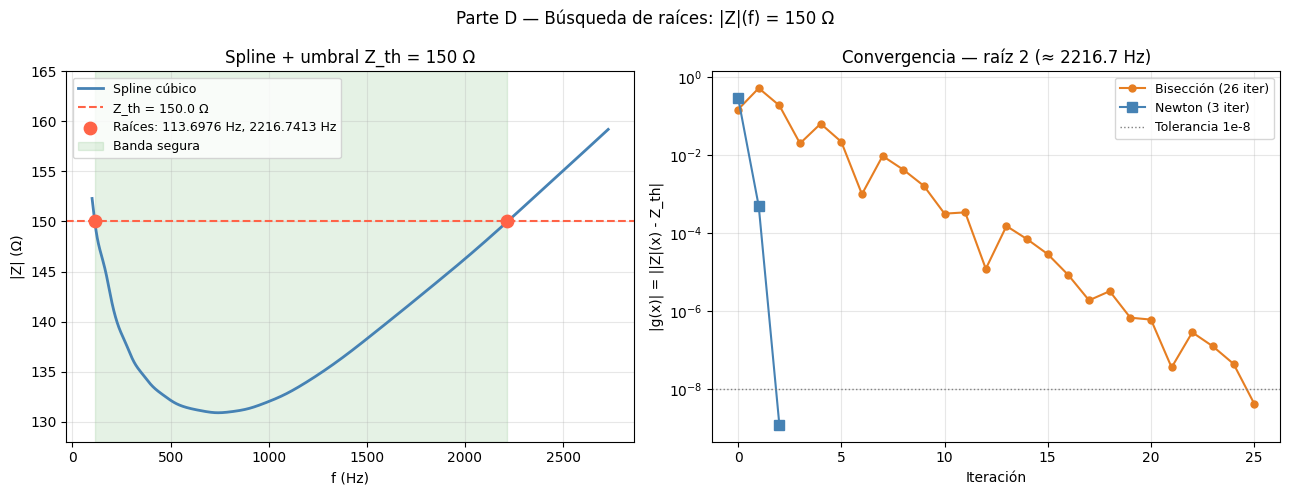


Gráfico guardado: parte_D_raices.png


In [2]:
"""
Métodos Numéricos — Parte D: Búsqueda de raíces
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# ── Datos + spline (mismo que partes anteriores) ──────────────────────────────
f = np.array([100,120,145,170,200,235,270,310,355,405,460,520,585,655,730,
              810,895,985,1080,1180,1290,1410,1540,1680,1830,1990,2160,2340,2530,2730],float)
Z = np.array([152.3,149.1,146.8,144.9,142.0,139.5,137.9,136.1,134.8,133.6,
              132.7,131.9,131.4,131.1,130.9,131.0,131.3,131.9,132.7,133.8,
              135.2,136.9,138.9,141.1,143.5,146.1,149.0,152.2,155.6,159.2],float)

cs  = CubicSpline(f, Z, bc_type='natural')
Z_th = 150.0                         # umbral del problema
g    = lambda x: cs(x) - Z_th       # función a anular
dg   = lambda x: cs(x, 1)           # derivada analítica del spline

# ═══════════════════════════════════════════════════════════════════════════════
# Localización de raíces: barrido de cambios de signo
# ═══════════════════════════════════════════════════════════════════════════════
ff_scan = np.linspace(f[0], f[-1], 10_000)
idx_sc  = np.where(np.diff(np.sign(g(ff_scan))))[0]

print("Intervalos con cambio de signo (raíces):")
for i in idx_sc:
    print(f"  [{ff_scan[i]:.2f}, {ff_scan[i+1]:.2f}] Hz")

# ═══════════════════════════════════════════════════════════════════════════════
# Métodos de búsqueda de raíces
# ═══════════════════════════════════════════════════════════════════════════════

def biseccion(a, b, tol=1e-8, max_iter=100):
    """Bisección clásica. Requiere g(a)·g(b) < 0."""
    hist = []
    for _ in range(max_iter):
        m = (a + b) / 2
        hist.append({'x': m, 'g': g(m)})
        if abs(g(m)) < tol or (b - a) / 2 < tol:
            break
        if g(a) * g(m) < 0: b = m
        else:                a = m
    return m, hist

def newton(x0, tol=1e-8, max_iter=50):
    """Newton-Raphson con derivada analítica del spline."""
    hist = []
    x = float(x0)
    for _ in range(max_iter):
        fx = g(x)
        hist.append({'x': x, 'g': fx})
        if abs(fx) < tol:
            break
        x -= fx / dg(x)    # x_{n+1} = x_n - f/f'
    return x, hist

# ── Raíz 1 ≈ 113.7 Hz ────────────────────────────────────────────────────────
r1_b, h1b = biseccion(100.0, 150.0)
r1_n, h1n = newton(115.0)

# ── Raíz 2 ≈ 2216.7 Hz ───────────────────────────────────────────────────────
r2_b, h2b = biseccion(2150.0, 2300.0)
r2_n, h2n = newton(2200.0)

# ── Resultados ────────────────────────────────────────────────────────────────
print("\n─── Raíz 1 ───")
print(f"  Bisección : {r1_b:.4f} Hz  ({len(h1b):2d} iter)  |Z|={cs(r1_b):.4f} Ω")
print(f"  Newton    : {r1_n:.4f} Hz  ({len(h1n):2d} iter)  |Z|={cs(r1_n):.4f} Ω")

print("\n─── Raíz 2 ───")
print(f"  Bisección : {r2_b:.4f} Hz  ({len(h2b):2d} iter)  |Z|={cs(r2_b):.4f} Ω")
print(f"  Newton    : {r2_n:.4f} Hz  ({len(h2n):2d} iter)  |Z|={cs(r2_n):.4f} Ω")

# ── Tabla de convergencia (raíz 2 para comparar) ─────────────────────────────
print("\n─── Convergencia raíz 2 ───")
print(f"{'it':>4}  {'Bisección x':>14}  {'|g|':>12}   {'it':>4}  {'Newton x':>14}  {'|g|':>12}")
max_rows = max(len(h2b), len(h2n))
for i in range(max_rows):
    sb = f"{h2b[i]['x']:14.6f}  {abs(h2b[i]['g']):12.4e}" if i < len(h2b) else ' '*28
    sn = f"{h2n[i]['x']:14.6f}  {abs(h2n[i]['g']):12.4e}" if i < len(h2n) else ' '*28
    print(f"{i+1:4d}  {sb}   {i+1:4d}  {sn}")

# ═══════════════════════════════════════════════════════════════════════════════
# Sensibilidad df/d|Z| en raíz 2
# ═══════════════════════════════════════════════════════════════════════════════
# Por la función implícita: d|Z|/df evaluada en la raíz.
# df/d|Z| = 1 / (d|Z|/df) — cuánto se desplaza la raíz por variación de 1 Ω
dZdf_r2 = cs(r2_b, 1)               # derivada analítica del spline en r2
dfdZ_r2 = 1.0 / dZdf_r2

print(f"\n─── Sensibilidad en raíz 2 (f ≈ {r2_b:.4f} Hz) ───")
print(f"  d|Z|/df = {dZdf_r2:.4f} Ω/Hz")
print(f"  df/d|Z| = {dfdZ_r2:.4f} Hz/Ω")
print(f"  → ΔZ = 1 Ω  ⟹  Δf ≈ {abs(dfdZ_r2):.4f} Hz en la raíz")
print(f"  → ΔZ = 0.1 Ω ⟹  Δf ≈ {0.1*abs(dfdZ_r2):.4f} Hz")

# ═══════════════════════════════════════════════════════════════════════════════
# Gráficos — 2 paneles
# ═══════════════════════════════════════════════════════════════════════════════
ff = np.linspace(f[0], f[-1], 3000)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Parte D — Búsqueda de raíces: |Z|(f) = 150 Ω', fontsize=12)

# Panel 1: spline + umbral + raíces ───────────────────────────────────────────
ax = axes[0]
ax.plot(ff, cs(ff), 'steelblue', lw=2, label='Spline cúbico')
ax.axhline(Z_th, color='tomato', ls='--', lw=1.5, label=f'Z_th = {Z_th} Ω')
ax.scatter([r1_b, r2_b], [Z_th, Z_th], color='tomato', s=80, zorder=6,
           label=f'Raíces: {r1_b:.4f} Hz, {r2_b:.4f} Hz')
# banda de operación segura (|Z| < Z_th)
ax.axvspan(r1_b, r2_b, alpha=0.10, color='green', label='Banda segura')
ax.set(xlabel='f (Hz)', ylabel='|Z| (Ω)',
       title='Spline + umbral Z_th = 150 Ω', ylim=(128, 165))
ax.legend(fontsize=9); ax.grid(alpha=.3)

# Panel 2: convergencia — |g(x)| vs iteración ─────────────────────────────────
ax = axes[1]
ax.semilogy([d['g'].__abs__() for d in h2b], 'o-', color='#e67e22',
            lw=1.5, ms=5, label=f'Bisección ({len(h2b)} iter)')
ax.semilogy([abs(d['g']) for d in h2n], 's-', color='steelblue',
            lw=1.5, ms=7, label=f'Newton ({len(h2n)} iter)')
ax.axhline(1e-8, color='gray', ls=':', lw=1, label='Tolerancia 1e-8')
ax.set(xlabel='Iteración', ylabel='|g(x)| = ||Z|(x) - Z_th|',
       title='Convergencia — raíz 2 (≈ 2216.7 Hz)')
ax.legend(fontsize=9); ax.grid(alpha=.3, which='both')

plt.tight_layout()
plt.savefig('parte_D_raices.png', dpi=150)
plt.show()
print("\nGráfico guardado: parte_D_raices.png")

Frecuencia del mínimo:    f*  = 742.1585 Hz
Impedancia en el mínimo:  |Z* = 130.8951 Ω
d|Z|/df  en f*:               = -7.6572e-19  (≈ 0 ✓)
d²|Z|/df² en f*:              = 0.000063 Ω/Hz²  → mínimo estable ✓

  #    f(Hz)       d|Z|/df
  1      100     -0.174903
  2      120     -0.130193
  3      145     -0.071501
  4      170     -0.087801
  5      200     -0.091474
  6      235     -0.053799
  7      270     -0.044758
  8      310     -0.038429
  9      355     -0.024866
 10      405     -0.020607
 11      460     -0.014387
 12      520     -0.010910
 13      585     -0.005366
 14      655     -0.003671
 15      730     -0.000818
 16      810      0.002512
 17      895      0.005080
 18      985      0.007633
 19     1080      0.009633
 20     1180      0.012013
 21     1290      0.013431
 22     1410      0.014881
 23     1540      0.015641
 24     1680      0.015852
 25     1830      0.016080
 26     1990      0.016578
 27     2160      0.017503
 28     2340      0.017894
 29     2

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/parte_c_derivacion.png'

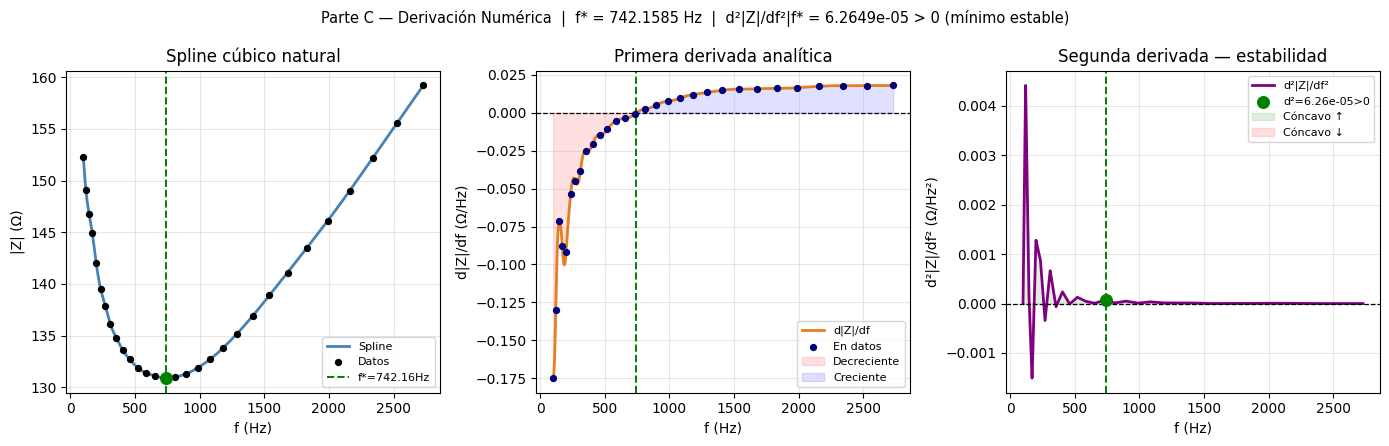

In [3]:
"""
Métodos Numéricos — Parte C: Derivación Numérica
Autor: [nombre]
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import brentq

# ── Datos ────────────────────────────────────────────────────────────────────
f = np.array([100,120,145,170,200,235,270,310,355,405,460,520,585,655,730,
              810,895,985,1080,1180,1290,1410,1540,1680,1830,1990,2160,2340,2530,2730], float)
Z = np.array([152.3,149.1,146.8,144.9,142.0,139.5,137.9,136.1,134.8,133.6,
              132.7,131.9,131.4,131.1,130.9,131.0,131.3,131.9,132.7,133.8,
              135.2,136.9,138.9,141.1,143.5,146.1,149.0,152.2,155.6,159.2], float)

# ── Spline cúbico natural + derivadas analíticas ─────────────────────────────
# .derivative(nu) diferencia analíticamente los polinomios de cada tramo
# → sin error de truncamiento por fórmula de diferencias finitas
cs = CubicSpline(f, Z, bc_type='natural')
d1 = cs.derivative(1)   # d|Z|/df
d2 = cs.derivative(2)   # d²|Z|/df²
d3 = cs.derivative(3)   # d³|Z|/df³ — para análisis de error

ff = np.linspace(f[0], f[-1], 4000)

# ── Localización precisa del mínimo ──────────────────────────────────────────
# Detectar cambio de signo en d1 sobre malla fina, refinar con brentq
idx = np.where(np.diff(np.sign(d1(ff))))[0]
f_min = brentq(d1, ff[idx[0]], ff[idx[0]+1], xtol=1e-8)

print(f"Frecuencia del mínimo:    f*  = {f_min:.4f} Hz")
print(f"Impedancia en el mínimo:  |Z* = {cs(f_min):.4f} Ω")
print(f"d|Z|/df  en f*:               = {d1(f_min):.4e}  (≈ 0 ✓)")
print(f"d²|Z|/df² en f*:              = {d2(f_min):.6f} Ω/Hz²  → {'mínimo estable ✓' if d2(f_min)>0 else 'máximo'}")

# ── Derivada en todos los puntos de datos ────────────────────────────────────
print(f"\n{'#':>3}  {'f(Hz)':>7}  {'d|Z|/df':>12}")
for i,(fi,di) in enumerate(zip(f, d1(f))):
    print(f"{i+1:3d}  {fi:7.0f}  {di:12.6f}")

# ── Análisis de error ─────────────────────────────────────────────────────────
# El error del spline depende de h (espaciado local): a mayor h, más libertad
# tiene el polinomio del tramo → peor representación de la curvatura real.
# Si se usaran diferencias finitas centradas: error ≈ h²/6 · f'''(ξ)
i_near = np.argmin(np.abs(f - f_min))
h = (f[i_near+1] - f[i_near-1]) / 2   # h promedio alrededor del mínimo
err_df = h**2 / 6 * abs(float(d3(f_min)))
print(f"\nEspaciado promedio en f*: h ≈ {h:.1f} Hz")
print(f"Error dif. finitas cent.: ≈ {err_df:.4e} Ω/Hz")
print(f"Reducir h de {h:.0f}→10 Hz: error cae factor ({h:.0f}/10)²={h**2/100:.0f}×")

# ── Gráficos ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle(f'Parte C — Derivación Numérica  |  f* = {f_min:.4f} Hz  |  '
             f'd²|Z|/df²|f* = {d2(f_min):.4e} > 0 (mínimo estable)', fontsize=10.5)

# |Z|(f)
ax = axes[0]
ax.plot(ff, cs(ff), 'steelblue', lw=2, label='Spline')
ax.scatter(f, Z, c='k', s=18, zorder=5, label='Datos')
ax.axvline(f_min, color='green', ls='--', lw=1.4, label=f'f*={f_min:.2f}Hz')
ax.scatter([f_min],[cs(f_min)], c='green', s=70, zorder=6)
ax.set(xlabel='f (Hz)', ylabel='|Z| (Ω)', title='Spline cúbico natural')
ax.legend(fontsize=8); ax.grid(alpha=.3)

# Primera derivada
ax = axes[1]
ax.plot(ff, d1(ff), '#e67e22', lw=2, label='d|Z|/df')
ax.scatter(f, d1(f), c='navy', s=18, zorder=5, label='En datos')
ax.axhline(0, c='k', lw=.9, ls='--')
ax.axvline(f_min, color='green', ls='--', lw=1.4)
ax.fill_between(ff, d1(ff), 0, where=d1(ff)<0, alpha=.12, color='red', label='Decreciente')
ax.fill_between(ff, d1(ff), 0, where=d1(ff)>0, alpha=.12, color='blue', label='Creciente')
ax.set(xlabel='f (Hz)', ylabel='d|Z|/df (Ω/Hz)', title='Primera derivada analítica')
ax.legend(fontsize=8); ax.grid(alpha=.3)

# Segunda derivada
ax = axes[2]
ax.plot(ff, d2(ff), 'purple', lw=2, label='d²|Z|/df²')
ax.axhline(0, c='k', lw=.9, ls='--')
ax.axvline(f_min, color='green', ls='--', lw=1.4)
ax.scatter([f_min],[d2(f_min)], c='green', s=70, zorder=6,
           label=f'd²={d2(f_min):.2e}>0')
ax.fill_between(ff, d2(ff), 0, where=d2(ff)>0, alpha=.12, color='green', label='Cóncavo ↑')
ax.fill_between(ff, d2(ff), 0, where=d2(ff)<0, alpha=.12, color='red',   label='Cóncavo ↓')
ax.set(xlabel='f (Hz)', ylabel='d²|Z|/df² (Ω/Hz²)', title='Segunda derivada — estabilidad')
ax.legend(fontsize=8); ax.grid(alpha=.3)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/parte_c_derivacion.png', dpi=150, bbox_inches='tight')
print("\nFigura guardada.")